# ClinVision AI : RSNA Pneumonia
## Notebook maître haute performance & généralisation

Pipeline complète : **Kaggle → DICOM → EDA → split patient-level → cache → benchmark → training → fine-tuning → threshold → ensemble → test → Grad-CAM → export**.

Le cahier des charges ClinVision demande RSNA, DICOM/pydicom, DenseNet, Grad-CAM, FastAPI/Streamlit et une évaluation multi-métriques. Ce notebook conserve ces éléments et ajoute un benchmark de modèles.

### Architectures
- EfficientNetV2B0
- DenseNet201
- ResNet50V2

### Principe
On ne promet pas 90 % sans exécution. Le notebook cherche la meilleure configuration sur **ton propre split**, protège le test contre toute sélection et mesure la généralisation.

### Références
- RSNA: https://www.kaggle.com/competitions/rsna-pneumonia-detection-challenge/data
- TensorFlow GPU: https://www.tensorflow.org/install/pip
- Apple Metal: https://developer.apple.com/metal/tensorflow-plugin/
- EfficientNetV2B0: https://www.tensorflow.org/api_docs/python/tf/keras/applications/EfficientNetV2B0
- DenseNet: https://www.tensorflow.org/api_docs/python/tf/keras/applications/DenseNet121
- ResNet50V2: https://www.tensorflow.org/api_docs/python/tf/keras/applications/ResNet50V2
- Pneu-ConViT 2026: https://doi.org/10.1049/ipr2.70434
- EfficientNet-B0 comparative study 2026: https://www.medrxiv.org/content/10.64898/2026.07.14.26358065v1.full

## 0 — Installation

### Mac Apple Silicon
```bash
python -m venv .venv
source .venv/bin/activate
pip install -U pip
pip install tensorflow tensorflow-metal
pip install numpy pandas scikit-learn matplotlib seaborn pillow opencv-python pydicom tqdm kaggle
```

### NVIDIA CUDA / Linux / WSL2
```bash
python -m venv .venv
source .venv/bin/activate
pip install -U pip
pip install "tensorflow[and-cuda]"
pip install numpy pandas scikit-learn matplotlib seaborn pillow opencv-python pydicom tqdm kaggle
```

### CPU
```bash
pip install tensorflow
pip install numpy pandas scikit-learn matplotlib seaborn pillow opencv-python pydicom tqdm kaggle
```

In [1]:
# ============================================================
# 1 — Imports
# ============================================================
import os, sys, json, time, math, random, zipfile, subprocess
import platform, warnings, shutil
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import pydicom
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision

warnings.filterwarnings("ignore")

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

/Users/mac/Downloads/clinvision-ai-final/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.11.16 (main, Sep 21 2026, 19:20:22) [Clang 21.0.0 (clang-2100.3.34.2)]
TensorFlow: 2.18.1
Keras: 3.15.1


In [2]:
# ============================================================
# 2 — CUDA / Metal / CPU
# ============================================================
gpus = tf.config.list_physical_devices("GPU")
is_apple_silicon = (
    sys.platform == "darwin"
    and platform.machine().lower() in {"arm64", "aarch64"}
)

if gpus and is_apple_silicon:
    BACKEND = "METAL"
elif gpus:
    BACKEND = "CUDA_OR_GPU"
else:
    BACKEND = "CPU"

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

if BACKEND == "CUDA_OR_GPU":
    try:
        mixed_precision.set_global_policy("mixed_float16")
        MIXED_PRECISION = True
    except Exception:
        mixed_precision.set_global_policy("float32")
        MIXED_PRECISION = False
else:
    mixed_precision.set_global_policy("float32")
    MIXED_PRECISION = False

print("=" * 60)
print("Backend:", BACKEND)
print("TensorFlow GPUs:", gpus)
print("Mixed precision:", MIXED_PRECISION)
print("=" * 60)

Backend: METAL
TensorFlow GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision: False


In [3]:
# ============================================================
# 3 — Configuration centrale
# ============================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Résolution recommandée :
# CUDA -> 512, Mac Metal -> 384, CPU -> 320.
if BACKEND == "CUDA_OR_GPU":
    IMAGE_SIZE = 512
    BATCH_SIZE = 8
elif BACKEND == "METAL":
    IMAGE_SIZE = 384
    BATCH_SIZE = 4
else:
    IMAGE_SIZE = 320
    BATCH_SIZE = 4

# Screening rapide : évite plusieurs heures par modèle.
RUN_SCREENING = True
SCREEN_FRACTION = 0.20
SCREEN_EPOCHS = 2

# Nombre de candidats complets après screening.
TOP_K_FINAL = 2

HEAD_EPOCHS = 8
FINETUNE_EPOCHS = 8
HEAD_LR = 3e-4
FINETUNE_LR = 5e-6
WEIGHT_DECAY = 1e-4
DROPOUT = 0.20
LABEL_SMOOTHING = 0.005
FINE_TUNE_FRACTION = 0.20

AUG_ROTATION = 0.025
AUG_TRANSLATION = 0.025
AUG_ZOOM = 0.08
AUG_CONTRAST = 0.10
USE_HORIZONTAL_FLIP = False

# "gray_rgb" : grayscale copié sur 3 canaux.
# "enhanced3": original / CLAHE / sharpened.
INPUT_REPRESENTATION = "gray_rgb"

MODEL_CANDIDATES = [
    "efficientnetv2b0",
    "densenet201",
    "resnet50v2",
]

print("IMAGE_SIZE =", IMAGE_SIZE)
print("BATCH_SIZE =", BATCH_SIZE)
print("Candidates =", MODEL_CANDIDATES)

IMAGE_SIZE = 384
BATCH_SIZE = 4
Candidates = ['efficientnetv2b0', 'densenet201', 'resnet50v2']


In [4]:
# ============================================================
# 4 — Dossiers projet
# ============================================================
candidate_roots = [
    Path.cwd(),
    Path.cwd() / "clinvision-ai-final",
    Path("/content/clinvision-ai-final"),
    Path("/content/Clinvision-AI"),
]

PROJECT_ROOT = next(
    (p.resolve() for p in candidate_roots if p.exists()),
    Path.cwd().resolve()
)

DATA_ROOT = PROJECT_ROOT / "data"
RAW_ROOT = DATA_ROOT / "raw"
CACHE_ROOT = DATA_ROOT / f"cache_{INPUT_REPRESENTATION}_{IMAGE_SIZE}"
MODELS_ROOT = PROJECT_ROOT / "models"
ARTIFACTS_ROOT = PROJECT_ROOT / "artifacts"

for p in [DATA_ROOT, RAW_ROOT, CACHE_ROOT, MODELS_ROOT, ARTIFACTS_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /Users/mac/Downloads/clinvision-ai-final


## 5 — Kaggle / RSNA

Le notebook télécharge automatiquement la compétition. Il cherche `~/.kaggle/kaggle.json`; dans Colab, il demande un upload si nécessaire.

Il faut avoir accès à la compétition RSNA et avoir accepté ses règles Kaggle.

In [5]:
# ============================================================
# 5.1 — Credentials Kaggle
# ============================================================
KAGGLE_DIR = Path.home() / ".kaggle"
KAGGLE_JSON = KAGGLE_DIR / "kaggle.json"

try:
    from google.colab import files
    if not KAGGLE_JSON.exists():
        print("Colab : uploadez kaggle.json")
        uploaded = files.upload()
        if "kaggle.json" in uploaded:
            KAGGLE_DIR.mkdir(parents=True, exist_ok=True)
            KAGGLE_JSON.write_bytes(uploaded["kaggle.json"])
            KAGGLE_JSON.chmod(0o600)
except ImportError:
    pass

if not KAGGLE_JSON.exists():
    raise FileNotFoundError(
        "kaggle.json absent. Placez-le dans ~/.kaggle/kaggle.json "
        "ou uploadez-le dans Colab."
    )

with open(KAGGLE_JSON, "r", encoding="utf-8") as f:
    kaggle_config = json.load(f)

if not {"username", "key"}.issubset(kaggle_config):
    raise ValueError("kaggle.json doit contenir username et key.")

print("✅ Kaggle :", kaggle_config["username"])

✅ Kaggle : ouaraskhelilrafik


In [6]:
# ============================================================
# 5.2 — Download + extraction
# ============================================================
COMPETITION = "rsna-pneumonia-detection-challenge"
DOWNLOAD_DIR = RAW_ROOT / "kaggle_download"
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

if list(RAW_ROOT.rglob("stage_2_train_labels.csv")):
    print("✅ Dataset déjà présent.")
else:
    cmd = [
        sys.executable, "-m", "kaggle",
        "competitions", "download",
        "-c", COMPETITION,
        "-p", str(DOWNLOAD_DIR)
    ]
    result = subprocess.run(
        cmd, capture_output=True, text=True
    )
    if result.returncode != 0:
        print(result.stdout)
        print(result.stderr)
        raise RuntimeError(
            "Kaggle download failed."
        )

    zips = list(DOWNLOAD_DIR.glob("*.zip"))
    if not zips:
        raise FileNotFoundError("Aucun ZIP téléchargé.")

    for z in zips:
        print("Extraction:", z.name)
        with zipfile.ZipFile(z, "r") as archive:
            archive.extractall(RAW_ROOT)

print("✅ RSNA prêt.")

✅ Dataset déjà présent.
✅ RSNA prêt.


In [7]:
# ============================================================
# 5.3 — Fichiers RSNA
# ============================================================
def find_file(root, name):
    matches = list(root.rglob(name))
    if not matches:
        raise FileNotFoundError(f"{name} introuvable.")
    return matches[0]

LABELS_CSV = find_file(RAW_ROOT, "stage_2_train_labels.csv")
DETAILED_CSV = find_file(RAW_ROOT, "stage_2_detailed_class_info.csv")
SAMPLE_CSV = find_file(RAW_ROOT, "stage_2_sample_submission.csv")

image_dirs = list(RAW_ROOT.rglob("stage_2_train_images"))
if not image_dirs:
    raise FileNotFoundError("stage_2_train_images absent.")
TRAIN_DICOM_DIR = image_dirs[0]

print("Labels :", LABELS_CSV)
print("Images :", TRAIN_DICOM_DIR)

Labels : /Users/mac/Downloads/clinvision-ai-final/data/raw/stage_2_train_labels.csv
Images : /Users/mac/Downloads/clinvision-ai-final/data/raw/stage_2_train_images


In [8]:
# ============================================================
# 6 — Labels image-level
# ============================================================
labels_raw = pd.read_csv(LABELS_CSV)
detailed_raw = pd.read_csv(DETAILED_CSV)

image_df = (
    labels_raw.groupby("patientId", as_index=False)
    .agg(
        Target=("Target", "max"),
        num_boxes=("Target", "size"),
        x=("x", lambda s: list(s.dropna())),
        y=("y", lambda s: list(s.dropna())),
        width=("width", lambda s: list(s.dropna())),
        height=("height", lambda s: list(s.dropna())),
    )
)

image_df["Target"] = image_df["Target"].astype(int)
image_df["dicom_path"] = image_df["patientId"].map(
    lambda pid: str(TRAIN_DICOM_DIR / f"{pid}.dcm")
)

image_df = image_df.merge(
    detailed_raw[["patientId", "class"]].drop_duplicates("patientId"),
    on="patientId",
    how="left"
)

missing = image_df[
    ~image_df["dicom_path"].map(Path).map(Path.exists)
]
if len(missing):
    raise FileNotFoundError(
        f"{len(missing)} DICOM manquants."
    )

print("Images :", len(image_df))
print("Positive rate :", f"{image_df['Target'].mean():.3%}")
print(image_df["class"].value_counts(dropna=False))

Images : 26684
Positive rate : 22.530%
class
No Lung Opacity / Not Normal    11821
Normal                           8851
Lung Opacity                     6012
Name: count, dtype: int64


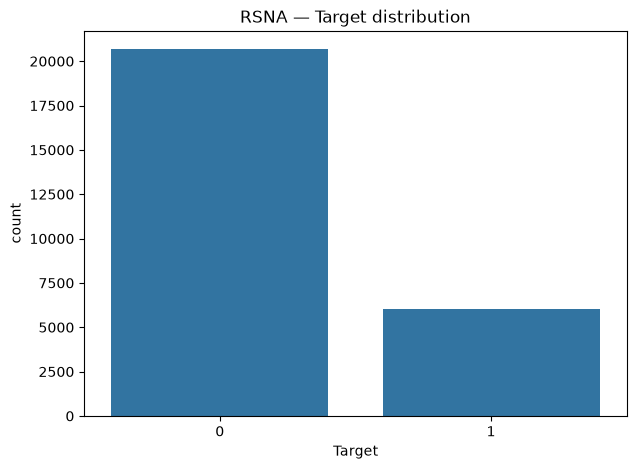

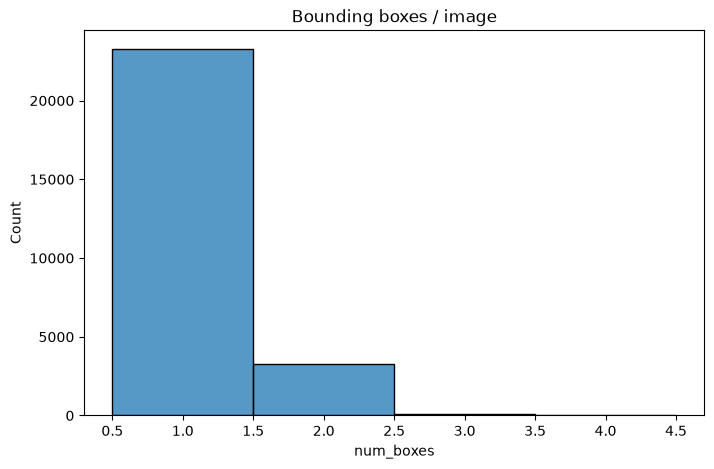

Unique patientId: 26684
Images with boxes: 26684


In [9]:
# ============================================================
# 6.1 — EDA
# ============================================================
plt.figure(figsize=(7, 5))
sns.countplot(data=image_df, x="Target")
plt.title("RSNA — Target distribution")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(image_df["num_boxes"], discrete=True)
plt.title("Bounding boxes / image")
plt.show()

print(
    "Unique patientId:",
    image_df["patientId"].nunique()
)
print(
    "Images with boxes:",
    int((image_df["num_boxes"] > 0).sum())
)

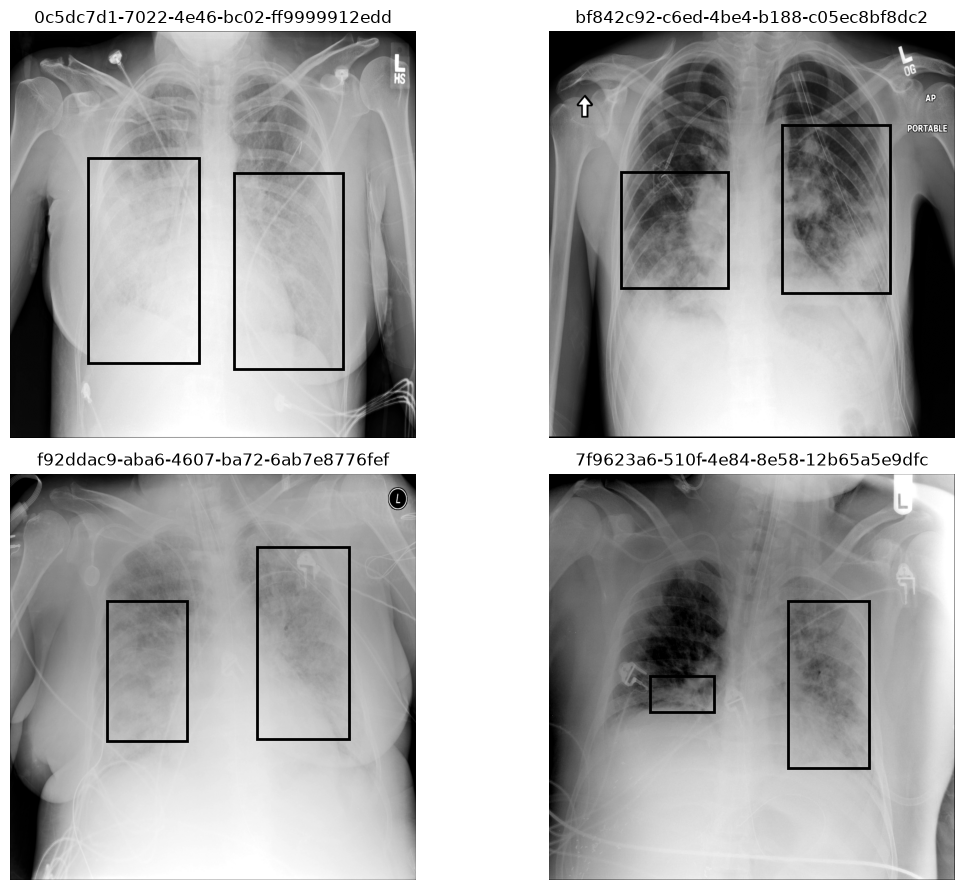

In [10]:
# ============================================================
# 6.2 — DICOM -> uint8 pour visualisation
# ============================================================
def dicom_to_uint8(path):
    """
    DICOM -> grayscale uint8.
    Gère rescale slope/intercept, MONOCHROME1 et percentiles.
    """
    ds = pydicom.dcmread(path, force=True)
    img = ds.pixel_array.astype(np.float32)

    slope = float(getattr(ds, "RescaleSlope", 1.0))
    intercept = float(getattr(ds, "RescaleIntercept", 0.0))
    img = img * slope + intercept

    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        img = img.max() - img

    lo, hi = np.percentile(img, [1, 99])
    if hi <= lo:
        lo, hi = float(img.min()), float(img.max())

    img = np.clip(
        (img - lo) / max(hi - lo, 1e-6),
        0, 1
    )
    return (img * 255).astype(np.uint8)

def show_boxes(df, n=4):
    """
    Montre des positives avec les annotations RSNA.
    """
    sample = df[df["Target"] == 1].sample(
        min(n, (df["Target"] == 1).sum()),
        random_state=SEED
    )

    fig, axes = plt.subplots(
        2, 2, figsize=(12, 9)
    )
    axes = np.ravel(axes)

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = dicom_to_uint8(row["dicom_path"])
        ax.imshow(img, cmap="gray")

        for x, y, w, h in zip(
            row["x"], row["y"],
            row["width"], row["height"]
        ):
            ax.add_patch(
                plt.Rectangle(
                    (x, y), w, h,
                    fill=False,
                    linewidth=2
                )
            )

        ax.set_title(row["patientId"])
        ax.axis("off")

    for ax in axes[len(sample):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_boxes(image_df)

## 7 — Split patient-level

70 % train, 15 % validation, 15 % test.

Le test ne sert ni à choisir l'architecture, ni le seuil.

In [11]:
# ============================================================
# 7 — Split
# ============================================================
patient_table = (
    image_df[["patientId", "Target"]]
    .drop_duplicates("patientId")
    .reset_index(drop=True)
)

train_pat, temp_pat = train_test_split(
    patient_table,
    test_size=0.30,
    stratify=patient_table["Target"],
    random_state=SEED
)

val_pat, test_pat = train_test_split(
    temp_pat,
    test_size=0.50,
    stratify=temp_pat["Target"],
    random_state=SEED
)

train_ids = set(train_pat["patientId"])
val_ids = set(val_pat["patientId"])
test_ids = set(test_pat["patientId"])

assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)

train_df = image_df[image_df["patientId"].isin(train_ids)].reset_index(drop=True)
val_df = image_df[image_df["patientId"].isin(val_ids)].reset_index(drop=True)
test_df = image_df[image_df["patientId"].isin(test_ids)].reset_index(drop=True)

print(
    "TRAIN:", len(train_df),
    f"| positive={train_df['Target'].mean():.3%}"
)
print(
    "VAL:", len(val_df),
    f"| positive={val_df['Target'].mean():.3%}"
)
print(
    "TEST:", len(test_df),
    f"| positive={test_df['Target'].mean():.3%}"
)
print("✅ no leakage.")

TRAIN: 18678 | positive=22.529%
VAL: 4003 | positive=22.533%
TEST: 4003 | positive=22.533%
✅ no leakage.


## 8 — Cache DICOM

Le cache réduit fortement le coût d'I/O/pydicom de tes anciens entraînements.

Le fichier cache reste en `[0,255]`. Chaque backbone applique son propre preprocessing **une seule fois dans le modèle**.

In [12]:
# ============================================================
# 8 — Cache
# ============================================================
def make_enhanced3(gray):
    """
    Représentation expérimentale :
      canal 0 = original
      canal 1 = CLAHE
      canal 2 = sharpened
    """
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    ).apply(gray)

    blur = cv2.GaussianBlur(
        gray, (0, 0), sigmaX=1.0
    )
    sharp = cv2.addWeighted(
        gray, 1.5, blur, -0.5, 0
    )

    return np.stack(
        [gray, clahe, sharp],
        axis=-1
    ).clip(0, 255).astype(np.uint8)

def convert_one(job):
    source, target = job

    gray = dicom_to_uint8(source)
    gray = cv2.resize(
        gray,
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=cv2.INTER_AREA
    )

    if INPUT_REPRESENTATION == "gray_rgb":
        rgb = np.repeat(
            gray[..., None],
            3,
            axis=-1
        )
    elif INPUT_REPRESENTATION == "enhanced3":
        rgb = make_enhanced3(gray)
    else:
        raise ValueError(INPUT_REPRESENTATION)

    Image.fromarray(
        rgb.astype(np.uint8),
        mode="RGB"
    ).save(
        target,
        format="PNG"
    )

def build_cache(df):
    """
    Conversion parallèle avec reprise.
    """
    CACHE_ROOT.mkdir(
        parents=True,
        exist_ok=True
    )

    jobs = []
    for pid, src in zip(
        df["patientId"],
        df["dicom_path"]
    ):
        target = CACHE_ROOT / f"{pid}.png"
        if not target.exists():
            jobs.append((src, target))

    print("À convertir:", len(jobs))

    if jobs:
        workers = max(
            2,
            min(6, os.cpu_count() or 4)
        )

        errors = []

        with ThreadPoolExecutor(
            max_workers=workers
        ) as ex:
            futures = [
                ex.submit(convert_one, j)
                for j in jobs
            ]

            for future in tqdm(
                as_completed(futures),
                total=len(futures),
                desc="DICOM -> PNG"
            ):
                try:
                    future.result()
                except Exception as exc:
                    errors.append(exc)

        if errors:
            raise RuntimeError(
                f"{len(errors)} erreurs. "
                f"Première: {errors[0]}"
            )

for df in [train_df, val_df, test_df]:
    build_cache(df)
    df["image_path"] = df["patientId"].map(
        lambda pid: str(
            CACHE_ROOT / f"{pid}.png"
        )
    )

print("✅ Cache prêt.")

À convertir: 18678


DICOM -> PNG: 100%|██████████| 18678/18678 [04:36<00:00, 67.49it/s] 


À convertir: 4003


DICOM -> PNG: 100%|██████████| 4003/4003 [01:00<00:00, 66.21it/s] 


À convertir: 4003


DICOM -> PNG: 100%|██████████| 4003/4003 [00:52<00:00, 75.67it/s] 


✅ Cache prêt.


In [13]:
# ============================================================
# 9 — Augmentations + tf.data
# ============================================================
augmentation_layers = keras.Sequential(
    [
        layers.RandomRotation(
            AUG_ROTATION,
            fill_mode="reflect"
        ),
        layers.RandomTranslation(
            AUG_TRANSLATION,
            AUG_TRANSLATION,
            fill_mode="reflect"
        ),
        layers.RandomZoom(
            (-AUG_ZOOM, AUG_ZOOM),
            (-AUG_ZOOM, AUG_ZOOM),
            fill_mode="reflect"
        ),
        layers.RandomContrast(
            AUG_CONTRAST
        )
    ],
    name="train_augmentation"
)

if USE_HORIZONTAL_FLIP:
    augmentation_layers = keras.Sequential(
        [
            layers.RandomFlip("horizontal"),
            augmentation_layers
        ],
        name="train_augmentation"
    )

AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(df, training=False):
    """
    Construit le dataset.
    Le shuffle est fait ici, pas dans fit().
    """
    paths = df["image_path"].astype(str).values
    labels = df["Target"].astype(np.float32).values

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if training:
        ds = ds.shuffle(
            min(len(df), 4096),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    def load(path, label):
        image = tf.io.decode_png(
            tf.io.read_file(path),
            channels=3
        )
        image = tf.image.convert_image_dtype(
            image,
            tf.float32
        ) * 255.0

        image = tf.ensure_shape(
            image,
            [IMAGE_SIZE, IMAGE_SIZE, 3]
        )

        return image, label

    ds = ds.map(
        load,
        num_parallel_calls=AUTOTUNE,
        deterministic=not training
    )

    if training:
        ds = ds.map(
            lambda x, y: (
                augmentation_layers(
                    x,
                    training=True
                ),
                y
            ),
            num_parallel_calls=AUTOTUNE,
            deterministic=False
        )

    return (
        ds.batch(BATCH_SIZE)
        .prefetch(AUTOTUNE)
    )

train_ds = make_dataset(train_df, True)
val_ds = make_dataset(val_df, False)
test_ds = make_dataset(test_df, False)

print("✅ tf.data ready.")

2026-09-26 16:27:49.438405: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-09-26 16:27:49.441702: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-09-26 16:27:49.442164: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1790436469.442647 20174777 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1790436469.443493 20174777 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


✅ tf.data ready.


## 10 — Modèles

TensorFlow documente un preprocessing différent pour les applications Keras. Nous l'appliquons directement dans chaque modèle afin d'éviter le double preprocessing.

EfficientNetV2, par défaut, inclut son preprocessing et reçoit des pixels `[0,255]`.

In [17]:
# ============================================================
# 10 — Model registry + builder
# ============================================================
MODEL_REGISTRY = {

    "efficientnetv2b0": {
        "builder": keras.applications.EfficientNetV2B0,
        "preprocess": None,
        "gradcam_layer": "top_activation",
    },

    "densenet201": {
        "builder": keras.applications.DenseNet201,
        "preprocess": keras.applications.densenet.preprocess_input,
        "gradcam_layer": "conv5_block32_concat",
    },

    "resnet50v2": {
        "builder": keras.applications.ResNet50V2,
        "preprocess": keras.applications.resnet_v2.preprocess_input,
        "gradcam_layer": "post_relu",
    },
}

def build_model(
    model_name,
    image_size=IMAGE_SIZE,
    dropout=DROPOUT,
):
    """
    Construit un classifieur binaire ClinVision.

    Architecture :

        Input
          ↓
        preprocessing spécifique
          ↓
        Backbone ImageNet
          ↓
        GlobalAveragePooling2D
          ↓
        BatchNormalization
          ↓
        Dropout
          ↓
        Dense(1, sigmoid)

    Returns
    -------
    model : keras.Model
        Modèle complet.

    backbone : keras.Model
        Backbone pré-entraîné utilisé pour le fine-tuning.
    """

    # --------------------------------------------------------
    # 1. Vérifier le nom du modèle.
    # --------------------------------------------------------

    if model_name not in MODEL_REGISTRY:

        raise ValueError(
            f"Modèle inconnu : {model_name}\n"
            f"Modèles disponibles : "
            f"{list(MODEL_REGISTRY.keys())}"
        )


    cfg = MODEL_REGISTRY[
        model_name
    ]


    print()
    print("=" * 60)
    print("BUILD MODEL")
    print("=" * 60)
    print("Model:", model_name)
    print("Image size:", image_size)


    # --------------------------------------------------------
    # 2. Entrée image.
    # --------------------------------------------------------
    #
    # Les données arrivent dans [0, 255].
    #
    # Le preprocessing spécifique est ensuite appliqué selon
    # le backbone.
    # --------------------------------------------------------

    inputs = keras.Input(
        shape=(
            image_size,
            image_size,
            3,
        ),
        dtype=tf.float32,
        name="xray",
    )


    x = inputs


    # --------------------------------------------------------
    # 3. Preprocessing spécifique.
    # --------------------------------------------------------
    #
    # DenseNet / ResNet utilisent preprocess_input.
    #
    # EfficientNetV2 possède son preprocessing intégré par défaut.
    # --------------------------------------------------------

    if cfg["preprocess"] is not None:

        x = cfg["preprocess"](
            x
        )


    # --------------------------------------------------------
    # 4. Construction du backbone.
    # --------------------------------------------------------
    #
    # ATTENTION :
    #
    # Nous NE donnons PAS :
    #
    #     name="backbone"
    #
    # afin d'éviter le KeyError EfficientNetV2.
    #
    # Keras choisira automatiquement un nom valide :
    #
    #     efficientnetv2-b0
    #     densenet201
    #     resnet50v2
    #
    # --------------------------------------------------------

    backbone = cfg["builder"](
        include_top=False,
        weights="imagenet",
        input_shape=(
            image_size,
            image_size,
            3,
        ),
        pooling=None,
    )


    # --------------------------------------------------------
    # 5. Stage A :
    #
    # backbone gelé.
    # --------------------------------------------------------

    backbone.trainable = False


    # --------------------------------------------------------
    # 6. Forward pass.
    #
    # training=False est important pour le Stage A :
    # les couches BatchNorm du backbone fonctionnent en mode
    # inférence pendant cette phase.
    # --------------------------------------------------------

    x = backbone(
        x,
        training=False,
    )


    # --------------------------------------------------------
    # 7. Global Average Pooling.
    # --------------------------------------------------------

    x = layers.GlobalAveragePooling2D(
        name="global_average_pool"
    )(x)


    # --------------------------------------------------------
    # 8. Batch Normalization de la tête.
    # --------------------------------------------------------

    x = layers.BatchNormalization(
        name="head_batch_norm"
    )(x)


    # --------------------------------------------------------
    # 9. Dropout.
    # --------------------------------------------------------

    x = layers.Dropout(
        dropout,
        name="head_dropout",
    )(x)


    # --------------------------------------------------------
    # 10. Classifieur binaire.
    #
    # dtype=float32 :
    # même si mixed precision est active sur GPU,
    # nous conservons la sortie finale en float32 pour
    # améliorer la stabilité numérique de sigmoid.
    # --------------------------------------------------------

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32",
        name="pneumonia_probability",
    )(x)


    # --------------------------------------------------------
    # 11. Créer le modèle final.
    # --------------------------------------------------------

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name=f"clinvision_{model_name}",
    )


    # --------------------------------------------------------
    # 12. Informations de contrôle.
    # --------------------------------------------------------

    print(
        "Backbone Keras name:",
        backbone.name,
    )

    print(
        "Backbone layers:",
        len(backbone.layers),
    )

    print(
        "Total model layers:",
        len(model.layers),
    )

    print("=" * 60)


    return model, backbone

def compile_model(model, lr):
    """
    AdamW + BCE. Les class weights restent à None pour
    l'expérience accuracy-focused.
    """
    return model.compile(
        optimizer=keras.optimizers.AdamW(
            learning_rate=lr,
            weight_decay=WEIGHT_DECAY,
            clipnorm=1.0
        ),
        loss=keras.losses.BinaryCrossentropy(
            label_smoothing=LABEL_SMOOTHING
        ),
        metrics=[
            keras.metrics.BinaryAccuracy(
                name="accuracy",
                threshold=0.5
            ),
            keras.metrics.AUC(
                name="auc",
                curve="ROC"
            ),
            keras.metrics.AUC(
                name="pr_auc",
                curve="PR"
            ),
            keras.metrics.Precision(
                name="precision",
                thresholds=0.5
            ),
            keras.metrics.Recall(
                name="recall",
                thresholds=0.5
            ),
        ]
    )

In [18]:
# ============================================================
# 10.1 — Callbacks accuracy-first
# ============================================================
def callbacks_for(model_name, stage):
    """
    Le checkpoint principal et le scheduler surveillent
    val_accuracy. Un checkpoint AUC est aussi conservé.
    """
    return [
        keras.callbacks.ModelCheckpoint(
            str(
                MODELS_ROOT
                / f"{model_name}_{stage}_best_accuracy.keras"
            ),
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            str(
                MODELS_ROOT
                / f"{model_name}_{stage}_best_auc.keras"
            ),
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_accuracy",
            mode="max",
            factor=0.3,
            patience=2,
            min_lr=1e-7,
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            mode="max",
            patience=4,
            restore_best_weights=True,
            verbose=1
        )
    ]

## 11 — Screening rapide

Chaque candidat est entraîné brièvement sur 20 % du train. Cela permet de sélectionner les architectures avant de lancer les trainings coûteux.

In [19]:
# ============================================================
# 11 — Screening
# ============================================================
screen_train_df, _ = train_test_split(
    train_df,
    train_size=SCREEN_FRACTION,
    stratify=train_df["Target"],
    random_state=SEED
)

screen_train_ds = make_dataset(
    screen_train_df,
    True
)

def screen_one(model_name):
    """
    Screening rapide : head-only + validation complète.
    """
    tf.keras.backend.clear_session()

    model, _ = build_model(model_name)
    compile_model(model, HEAD_LR)

    start = time.time()

    history = model.fit(
        screen_train_ds,
        validation_data=val_ds,
        epochs=SCREEN_EPOCHS,
        class_weight=None,
        callbacks=callbacks_for(
            model_name,
            "screen"
        ),
        verbose=1
    )

    minutes = (
        time.time() - start
    ) / 60.0

    h = pd.DataFrame(
        history.history
    )

    return {
        "model": model_name,
        "val_accuracy": float(
            h["val_accuracy"].max()
        ),
        "val_auc": float(
            h["val_auc"].max()
        ),
        "val_pr_auc": float(
            h["val_pr_auc"].max()
        ),
        "minutes": minutes
    }

screen_rows = []

if RUN_SCREENING:
    for name in MODEL_CANDIDATES:
        screen_rows.append(
            screen_one(name)
        )
else:
    for name in MODEL_CANDIDATES:
        screen_rows.append(
            {
                "model": name,
                "val_accuracy": np.nan,
                "val_auc": np.nan,
                "val_pr_auc": np.nan,
                "minutes": 0.0
            }
        )

screening_df = pd.DataFrame(
    screen_rows
).sort_values(
    ["val_accuracy", "val_auc"],
    ascending=False
).reset_index(drop=True)

display(screening_df)

screening_df.to_csv(
    ARTIFACTS_ROOT / "screening.csv",
    index=False
)

FINAL_MODELS = (
    screening_df["model"]
    .head(TOP_K_FINAL)
    .tolist()
)

print("✅ Selected:", FINAL_MODELS)


BUILD MODEL
Model: efficientnetv2b0
Image size: 384
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Backbone Keras name: efficientnetv2-b0
Backbone layers: 270
Total model layers: 6
Epoch 1/2


2026-09-26 16:41:10.764464: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


934/934 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7290 - auc: 0.6544 - loss: 0.5710 - pr_auc: 0.3331 - precision: 0.3623 - recall: 0.2675
Epoch 1: val_accuracy improved from None to 0.79615, saving model to /Users/mac/Downloads/clinvision-ai-final/models/efficientnetv2b0_screen_best_accuracy.keras

Epoch 1: finished saving model to /Users/mac/Downloads/clinvision-ai-final/models/efficientnetv2b0_screen_best_accuracy.keras

Epoch 1: val_auc improved from None to 0.78508, saving model to /Users/mac/Downloads/clinvision-ai-final/models/efficientnetv2b0_screen_best_auc.keras

Epoch 1: finished saving model to /Users/mac/Downloads/clinvision-ai-final/models/efficientnetv2b0_screen_best_auc.keras
934/934 ━━━━━━━━━━━━━━━━━━━━ 104s 102ms/step - accuracy: 0.7290 - auc: 0.6544 - loss: 0.5710 - pr_auc: 0.3331 - precision: 0.3623 - recall: 0.2675 - val_accuracy: 0.7962 - val_auc: 0.7851 - val_loss: 0.4639 - val_pr_auc: 0.4836 - val_precision: 0.5814 - val_recall: 0.3404 - learning_rate: 3.00

,model,val_accuracy,val_auc,val_pr_auc,minutes
0,densenet201,0.813640,0.820752,0.586792,76.975550
1,resnet50v2,0.807644,0.799890,0.539013,6.751406
2,efficientnetv2b0,0.797152,0.787356,0.489750,3.823289


✅ Selected: ['densenet201', 'resnet50v2']


## 12 — Training final : Stage A + Stage B

Le modèle sélectionné est d'abord entraîné avec backbone gelé, puis rechargé depuis son meilleur checkpoint accuracy et fine-tuné.

In [20]:
# ============================================================
# 12 — Fine-tuning helper
# ============================================================
def configure_finetuning(
    model,
    backbone
):
    """
    Dégèle seulement les dernières couches du backbone.
    BatchNorm reste gelée.
    """
    backbone.trainable = True

    for layer in backbone.layers:
        layer.trainable = False

    n = max(
        1,
        int(
            len(backbone.layers)
            * FINE_TUNE_FRACTION
        )
    )

    selected = backbone.layers[-n:]

    for layer in selected:
        layer.trainable = not isinstance(
            layer,
            layers.BatchNormalization
        )

    # Tête toujours trainable.
    for name in [
        "global_average_pool",
        "head_batch_norm",
        "head_dropout",
        "pneumonia_probability"
    ]:
        model.get_layer(name).trainable = True

    return n

def train_complete(model_name):
    """
    Pipeline complète d'un modèle.
    """
    print("\n" + "=" * 70)
    print("FINAL TRAIN:", model_name)
    print("=" * 70)

    tf.keras.backend.clear_session()

    model, backbone = build_model(
        model_name
    )

    # ----------------------------
    # Stage A
    # ----------------------------
    compile_model(
        model,
        HEAD_LR
    )

    hist_head = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=HEAD_EPOCHS,
        class_weight=None,
        callbacks=callbacks_for(
            model_name,
            "head"
        ),
        verbose=1
    )

    head_path = (
        MODELS_ROOT
        / f"{model_name}_head_best_accuracy.keras"
    )

    if not head_path.exists():
        raise FileNotFoundError(head_path)

    # Recharger le meilleur Stage A accuracy.
    model = keras.models.load_model(
        head_path,
        compile=False
    )

    backbone = model.get_layer(
        "backbone"
    )

    # ----------------------------
    # Stage B
    # ----------------------------
    n_ft = configure_finetuning(
        model,
        backbone
    )

    compile_model(
        model,
        FINETUNE_LR
    )

    hist_ft = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FINETUNE_EPOCHS,
        class_weight=None,
        callbacks=callbacks_for(
            model_name,
            "finetune"
        ),
        verbose=1
    )

    print(
        f"Fine-tuned layers: {n_ft}"
    )

    return model, backbone, hist_head, hist_ft

trained_models = {}
histories = {}

for name in FINAL_MODELS:
    result = train_complete(name)
    trained_models[name] = result[:2]
    histories[name] = {
        "head": result[2],
        "finetune": result[3]
    }

print(
    "✅ Final training finished."
)


FINAL TRAIN: densenet201

BUILD MODEL
Model: densenet201
Image size: 384
Backbone Keras name: densenet201
Backbone layers: 707
Total model layers: 6
Epoch 1/8
4670/4670 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.7916 - auc: 0.7579 - loss: 0.4761 - pr_auc: 0.4890 - precision: 0.5710 - recall: 0.3018
Epoch 1: val_accuracy improved from None to 0.81839, saving model to /Users/mac/Downloads/clinvision-ai-final/models/densenet201_head_best_accuracy.keras

Epoch 1: finished saving model to /Users/mac/Downloads/clinvision-ai-final/models/densenet201_head_best_accuracy.keras

Epoch 1: val_auc improved from None to 0.83354, saving model to /Users/mac/Downloads/clinvision-ai-final/models/densenet201_head_best_auc.keras

Epoch 1: finished saving model to /Users/mac/Downloads/clinvision-ai-final/models/densenet201_head_best_auc.keras
4670/4670 ━━━━━━━━━━━━━━━━━━━━ 1339s 284ms/step - accuracy: 0.7916 - auc: 0.7579 - loss: 0.4761 - pr_auc: 0.4890 - precision: 0.5710 - recall: 0.3018 - val_acc

ValueError: No such layer: backbone. Existing layers are: ['xray', 'densenet201', 'global_average_pool', 'head_batch_norm', 'head_dropout', 'pneumonia_probability'].

## 13 — Évaluation stricte

Le seuil est optimisé sur validation uniquement.

On compare :
- accuracy @0.5 ;
- accuracy @selected;
- ROC-AUC;
- PR-AUC;
- Precision;
- Recall;
- Specificity;
- F1.

In [ ]:
# ============================================================
# 13 — Evaluation
# ============================================================
def predict_probs(model, ds):
    return model.predict(
        ds,
        verbose=1
    ).reshape(-1)

def metrics_at(y_true, probs, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    probs = np.asarray(probs).reshape(-1)
    pred = (probs >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        pred,
        labels=[0,1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if tn + fp > 0
        else 0.0
    )

    return {
        "accuracy": accuracy_score(
            y_true, pred
        ),
        "precision": precision_score(
            y_true, pred, zero_division=0
        ),
        "recall": recall_score(
            y_true, pred, zero_division=0
        ),
        "specificity": specificity,
        "f1": f1_score(
            y_true, pred, zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_true, probs
        ),
        "pr_auc": average_precision_score(
            y_true, probs
        ),
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn)
    }

def find_best_threshold(y_true, probs):
    """
    Optimise l'accuracy de validation.
    """
    rows = []

    for threshold in np.arange(
        0.05, 0.951, 0.005
    ):
        rows.append(
            {
                "threshold": threshold,
                **metrics_at(
                    y_true,
                    probs,
                    threshold
                )
            }
        )

    df = pd.DataFrame(rows)
    idx = df["accuracy"].idxmax()

    return (
        float(
            df.loc[idx, "threshold"]
        ),
        df
    )

clean_train_ds = make_dataset(
    train_df,
    False
)

evaluation_rows = []
model_predictions = {}

for name, (model, backbone) in trained_models.items():

    print("\nEvaluating:", name)

    p_train = predict_probs(
        model,
        clean_train_ds
    )

    p_val = predict_probs(
        model,
        val_ds
    )

    p_test = predict_probs(
        model,
        test_ds
    )

    threshold, threshold_df = (
        find_best_threshold(
            val_df["Target"].values,
            p_val
        )
    )

    for split_name, y_true, probs in [
        ("train", train_df["Target"].values, p_train),
        ("validation", val_df["Target"].values, p_val),
        ("test", test_df["Target"].values, p_test),
    ]:
        m05 = metrics_at(
            y_true,
            probs,
            0.5
        )

        ms = metrics_at(
            y_true,
            probs,
            threshold
        )

        evaluation_rows.append(
            {
                "model": name,
                "split": split_name,
                "threshold_from_validation": threshold,
                "accuracy_at_0.5": m05["accuracy"],
                "accuracy_selected": ms["accuracy"],
                "roc_auc": m05["roc_auc"],
                "pr_auc": m05["pr_auc"],
                "precision_selected": ms["precision"],
                "recall_selected": ms["recall"],
                "specificity_selected": ms["specificity"],
                "f1_selected": ms["f1"],
                "tp": ms["tp"],
                "tn": ms["tn"],
                "fp": ms["fp"],
                "fn": ms["fn"],
            }
        )

    model_predictions[name] = {
        "train": p_train,
        "val": p_val,
        "test": p_test,
        "threshold": threshold
    }

    threshold_df.to_csv(
        ARTIFACTS_ROOT
        / f"{name}_thresholds.csv",
        index=False
    )

evaluation_df = pd.DataFrame(
    evaluation_rows
)

display(
    evaluation_df.sort_values(
        ["split", "accuracy_selected"],
        ascending=[True, False]
    )
)

evaluation_df.to_csv(
    ARTIFACTS_ROOT / "evaluation.csv",
    index=False
)

In [ ]:
# ============================================================
# 13.1 — Ensemble
# ============================================================
ensemble = None

if len(FINAL_MODELS) >= 2:

    weights = np.ones(
        len(FINAL_MODELS),
        dtype=np.float64
    )
    weights /= weights.sum()

    p_val = np.vstack([
        model_predictions[n]["val"]
        for n in FINAL_MODELS
    ])

    p_test = np.vstack([
        model_predictions[n]["test"]
        for n in FINAL_MODELS
    ])

    p_train = np.vstack([
        model_predictions[n]["train"]
        for n in FINAL_MODELS
    ])

    ens_val = np.average(
        p_val,
        axis=0,
        weights=weights
    )
    ens_test = np.average(
        p_test,
        axis=0,
        weights=weights
    )
    ens_train = np.average(
        p_train,
        axis=0,
        weights=weights
    )

    ens_threshold, ens_table = (
        find_best_threshold(
            val_df["Target"].values,
            ens_val
        )
    )

    ensemble = {
        "models": FINAL_MODELS,
        "weights": weights.tolist(),
        "threshold": ens_threshold,
        "train": metrics_at(
            train_df["Target"].values,
            ens_train,
            ens_threshold
        ),
        "validation": metrics_at(
            val_df["Target"].values,
            ens_val,
            ens_threshold
        ),
        "test": metrics_at(
            test_df["Target"].values,
            ens_test,
            ens_threshold
        )
    }

    print(
        json.dumps(
            ensemble,
            indent=2
        )
    )

    ens_table.to_csv(
        ARTIFACTS_ROOT
        / "ensemble_thresholds.csv",
        index=False
    )
else:
    print("Ensemble skipped.")

## 14 — Champion

Le champion est choisi sur validation. Le test ne sert qu'à confirmer.

In [ ]:
# ============================================================
# 14 — Champion selection
# ============================================================
candidates = []

for name in FINAL_MODELS:
    row = evaluation_df[
        (evaluation_df["model"] == name)
        & (evaluation_df["split"] == "validation")
    ].iloc[0]

    candidates.append(
        {
            "candidate": name,
            "kind": "single",
            "val_accuracy_05": row[
                "accuracy_at_0.5"
            ],
            "val_accuracy_selected": row[
                "accuracy_selected"
            ],
            "val_auc": row["roc_auc"]
        }
    )

if ensemble is not None:
    candidates.append(
        {
            "candidate": "ensemble",
            "kind": "ensemble",
            "val_accuracy_05": ensemble[
                "validation"
            ]["accuracy"],
            "val_accuracy_selected": ensemble[
                "validation"
            ]["accuracy"],
            "val_auc": ensemble[
                "validation"
            ]["roc_auc"]
        }
    )

champion_df = pd.DataFrame(
    candidates
).sort_values(
    ["val_accuracy_05", "val_auc"],
    ascending=False
).reset_index(drop=True)

display(champion_df)

CHAMPION = champion_df.iloc[
    0
]["candidate"]

print("✅ Champion:", CHAMPION)

In [ ]:
# ============================================================
# 14.1 — Courbes du champion
# ============================================================
if CHAMPION == "ensemble":
    val_probs = ens_val
    test_probs = ens_test
    threshold = ensemble["threshold"]
    champion_model_name = FINAL_MODELS[0]
else:
    val_probs = model_predictions[
        CHAMPION
    ]["val"]
    test_probs = model_predictions[
        CHAMPION
    ]["test"]
    threshold = model_predictions[
        CHAMPION
    ]["threshold"]
    champion_model_name = CHAMPION

yv = val_df["Target"].values
yt = test_df["Target"].values

fpr_v, tpr_v, _ = roc_curve(yv, val_probs)
fpr_t, tpr_t, _ = roc_curve(yt, test_probs)

plt.figure(figsize=(8,6))
plt.plot(
    fpr_v,
    tpr_v,
    label=f"Val AUC={roc_auc_score(yv,val_probs):.4f}"
)
plt.plot(
    fpr_t,
    tpr_t,
    label=f"Test AUC={roc_auc_score(yt,test_probs):.4f}"
)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ClinVision ROC")
plt.grid(True)
plt.legend()
plt.show()

pv, rv, _ = precision_recall_curve(yv, val_probs)
pt, rt, _ = precision_recall_curve(yt, test_probs)

plt.figure(figsize=(8,6))
plt.plot(
    rv, pv,
    label=f"Val PR-AUC={average_precision_score(yv,val_probs):.4f}"
)
plt.plot(
    rt, pt,
    label=f"Test PR-AUC={average_precision_score(yt,test_probs):.4f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("ClinVision Precision-Recall")
plt.grid(True)
plt.legend()
plt.show()

test_pred = (
    test_probs >= threshold
).astype(int)

cm = confusion_matrix(
    yt,
    test_pred,
    labels=[0,1]
)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Pneumonia",
        "Pneumonia"
    ],
    yticklabels=[
        "No Pneumonia",
        "Pneumonia"
    ]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    f"Test confusion matrix @ {threshold:.3f}"
)
plt.show()

## 15 — Grad-CAM

Grad-CAM sert ici à expliquer les zones influentes pour le réseau. Ce n'est pas une segmentation médicale certaine.

In [ ]:
# ============================================================
# 15 — Grad-CAM
# ============================================================
def gradcam_heatmap(
    model,
    model_name,
    image_batch
):
    """
    Grad-CAM pour P(Pneumonia).
    """
    backbone = model.get_layer(
        "backbone"
    )

    target_name = MODEL_REGISTRY[
        model_name
    ]["gradcam"]

    try:
        target = backbone.get_layer(
            target_name
        )
    except ValueError:
        target = None
        for layer in reversed(
            backbone.layers
        ):
            try:
                if layer.output.shape.rank == 4:
                    target = layer
                    break
            except Exception:
                continue

        if target is None:
            raise RuntimeError(
                "Aucune feature map 4D."
            )

    grad_model = keras.Model(
        model.inputs,
        [
            target.output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_out, pred = grad_model(
            image_batch,
            training=False
        )
        score = pred[:,0]

    grads = tape.gradient(
        score,
        conv_out
    )

    if grads is None:
        raise RuntimeError(
            "Gradients indisponibles."
        )

    weights = tf.reduce_mean(
        grads,
        axis=(1,2)
    )[0]

    conv_out = conv_out[0]

    cam = tf.reduce_sum(
        conv_out
        * weights[
            tf.newaxis,
            tf.newaxis,
            :
        ],
        axis=-1
    )

    cam = tf.maximum(
        cam,
        0
    )
    cam /= (
        tf.reduce_max(cam)
        + 1e-8
    )

    return cam.numpy()

def overlay_cam(
    image_rgb,
    heatmap,
    alpha=0.40
):
    """
    Heatmap + image originale.
    """
    h = np.uint8(
        np.clip(
            heatmap,
            0,
            1
        ) * 255
    )

    h = cv2.applyColorMap(
        h,
        cv2.COLORMAP_JET
    )

    h = cv2.cvtColor(
        h,
        cv2.COLOR_BGR2RGB
    )

    h = cv2.resize(
        h,
        (
            image_rgb.shape[1],
            image_rgb.shape[0]
        )
    )

    base = np.uint8(
        np.clip(
            image_rgb,
            0,
            255
        )
    )

    return cv2.addWeighted(
        base,
        1-alpha,
        h,
        alpha,
        0
    )

In [ ]:
# ============================================================
# 15.1 — Grad-CAM exemple
# ============================================================
if champion_model_name in trained_models:
    grad_model = trained_models[
        champion_model_name
    ][0]

    sample = (
        val_df[val_df["Target"] == 1]
        .sample(
            1,
            random_state=SEED
        )
        .iloc[0]
    )

    rgb = np.array(
        Image.open(
            sample["image_path"]
        ).convert("RGB")
    )

    batch = np.expand_dims(
        rgb.astype(np.float32),
        0
    )

    probability = float(
        grad_model.predict(
            batch,
            verbose=0
        )[0,0]
    )

    cam = gradcam_heatmap(
        grad_model,
        champion_model_name,
        batch
    )

    overlay = overlay_cam(
        rgb,
        cam
    )

    fig, ax = plt.subplots(
        1, 3,
        figsize=(15,5)
    )

    ax[0].imshow(rgb)
    ax[0].set_title(
        f"Original p={probability:.3f}"
    )
    ax[0].axis("off")

    ax[1].imshow(
        cam,
        cmap="jet"
    )
    ax[1].set_title("Grad-CAM")
    ax[1].axis("off")

    ax[2].imshow(overlay)
    ax[2].set_title("Overlay")
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print(
        "Champion ensemble : utilisez un modèle individuel "
        "de l'ensemble pour Grad-CAM."
    )

In [ ]:
# ============================================================
# 16 — Export final pour le déploiement
# ============================================================
manifest = {
    "image_size": IMAGE_SIZE,
    "input_representation": INPUT_REPRESENTATION,
    "champion": CHAMPION,
    "final_models": FINAL_MODELS,
    "selection_primary": "validation_accuracy_at_0.5",
    "selection_secondary": "validation_auc",
}

if CHAMPION == "ensemble":
    manifest["type"] = "ensemble"
    manifest["weights"] = ensemble["weights"]
    manifest["threshold"] = ensemble["threshold"]

    # FastAPI actuel peut utiliser le fallback single model.
    fallback = trained_models[
        FINAL_MODELS[0]
    ][0]

    fallback_path = (
        MODELS_ROOT
        / "clinvision_pneumonia.keras"
    )

    fallback.save(
        fallback_path
    )
else:
    manifest["type"] = "single"
    manifest["model_name"] = CHAMPION
    manifest["threshold"] = model_predictions[
        CHAMPION
    ]["threshold"]

    final_model = trained_models[
        CHAMPION
    ][0]

    final_path = (
        MODELS_ROOT
        / "clinvision_pneumonia.keras"
    )

    final_model.save(
        final_path
    )

with open(
    ARTIFACTS_ROOT
    / "clinvision_manifest.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        manifest,
        f,
        indent=2
    )

# Rapport global.
final_report = {
    "hardware": {
        "backend": BACKEND,
        "tensorflow": tf.__version__,
        "image_size": IMAGE_SIZE,
        "batch_size": BATCH_SIZE,
        "mixed_precision": MIXED_PRECISION
    },
    "dataset": {
        "train": len(train_df),
        "validation": len(val_df),
        "test": len(test_df),
        "positive_rate": float(
            image_df["Target"].mean()
        )
    },
    "champion": manifest
}

with open(
    ARTIFACTS_ROOT
    / "final_report.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        final_report,
        f,
        indent=2
    )

print(
    json.dumps(
        final_report,
        indent=2
    )
)

print("✅ Model + manifest + report exported.")

# Contrôle final

### À retenir

- Le test reste indépendant.
- Le seuil est sélectionné sur validation.
- Une accuracy élevée ne suffit pas : vérifier recall, specificity, precision, F1 et AUC.
- Le split doit rester au niveau `patientId`.
- Le 90 % n'est pas garanti : il doit être obtenu et confirmé par l'expérimentation.

### Si l'accuracy reste sous 90 %

Ne pas simplement augmenter les epochs indéfiniment. Les prochaines expériences recommandées sont :
1. comparer `gray_rgb` vs `enhanced3` ;
2. comparer 384 vs 512 sur le meilleur backbone compatible avec le GPU ;
3. tester le meilleur modèle sur un nouveau split/fold patient-level ;
4. tester éventuellement un ensemble ;
5. faire une validation externe pour la généralisation.